## GA

In [1]:
import numpy as np

# Rastrigin function
def rastrigin(x):
    return 10 * len(x) + sum([xi**2 - 10 * np.cos(2 * np.pi * xi) for xi in x])

# GA Parameters
pop_size = 50
n_gen = 100
dim = 2
bounds = [-5.12, 5.12]
mutation_rate = 0.1

# Initialization
population = np.random.uniform(bounds[0], bounds[1], (pop_size, dim))

for gen in range(n_gen):
    fitness = np.array([rastrigin(ind) for ind in population])
    parents = population[np.argsort(fitness)[:pop_size // 2]]
    
    # Crossover
    children = []
    while len(children) < pop_size:
        p1, p2 = parents[np.random.randint(0, len(parents), 2)]
        child = (p1 + p2) / 2  # arithmetic crossover
        if np.random.rand() < mutation_rate:
            child += np.random.normal(0, 0.1, dim)  # Gaussian mutation
        child = np.clip(child, bounds[0], bounds[1])
        children.append(child)
    
    population = np.array(children)

best = population[np.argmin([rastrigin(ind) for ind in population])]
print("GA best solution:", best, "Value:", rastrigin(best))

GA best solution: [-0.00281106 -0.00484819] Value: 0.006230493630035028


## CMA

In [2]:
!pip install cma

In [6]:
import cma

# Initial mean and standard deviation
init_mean = [0, 0]
sigma = 0.5  # step size

# Run CMA-ES
result = cma.fmin(rastrigin, init_mean, sigma, options={'maxiter': 100})
print("CMA-ES best solution:", result[0], "Value:", rastrigin(result[0]))


(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=1104798, Fri May 23 11:21:17 2025)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1      6 9.931594512181938e+00 1.0e+00 4.26e-01  4e-01  4e-01 0:00.0
    2     12 2.167885539047516e+01 1.1e+00 3.00e-01  2e-01  3e-01 0:00.0
    3     18 9.388781669599464e+00 1.1e+00 3.04e-01  2e-01  3e-01 0:00.0
   75    450 0.000000000000000e+00 1.7e+00 2.53e-06  2e-09  2e-09 0:00.1
termination on tolfun=1e-11 (Fri May 23 11:21:18 2025)
final/bestever f-value = 0.000000e+00 0.000000e+00
incumbent solution: [-1.2408389937781082e-09, 9.625832145881296e-10]
std deviation: [2.4593562177726663e-09, 2.105974278543308e-09]
CMA-ES best solution: [-3.52991922e-09  5.18279183e-11] Value: 0.0


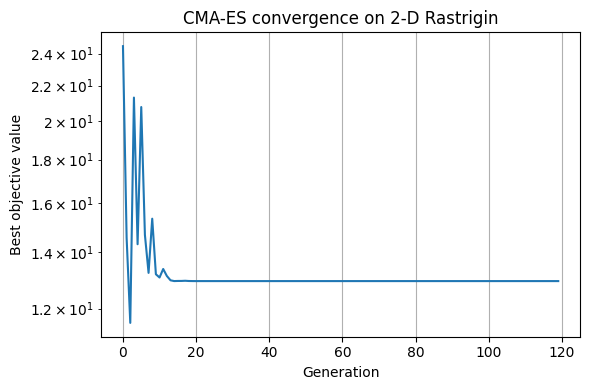

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ------- Helper: Rastrigin function ---------
def rastrigin(x: np.ndarray) -> float:
    """Rastrigin function."""
    return 10 * len(x) + np.sum(x ** 2 - 10 * np.cos(2 * np.pi * x))


# ------- Simple CMA-ES implementation (minimal) ---------
def cma_es(
    f,
    n_dim: int = 2,
    n_iter: int = 150,
    initial_mean: np.ndarray | None = None,
    sigma: float = 0.5,
):
    """Very small-scale CMA-ES for demonstration."""
    if initial_mean is None:
        initial_mean = np.zeros(n_dim)

    # Strategy parameters
    lam = int(4 + np.floor(3 * np.log(n_dim)))  # population size
    mu = lam // 2
    weights = np.log(mu + 0.5) - np.log(np.arange(1, mu + 1))
    weights /= np.sum(weights)
    mu_eff = 1 / np.sum(weights**2)

    # Adaptation parameters
    cc = (4 + mu_eff / n_dim) / (n_dim + 4 + 2 * mu_eff / n_dim)
    cs = (mu_eff + 2) / (n_dim + mu_eff + 5)
    c1 = 2 / ((n_dim + 1.3) ** 2 + mu_eff)
    alpha_mu = 2
    cmu = min(
        1 - c1,
        alpha_mu
        * (mu_eff - 2 + 1 / mu_eff)
        / ((n_dim + 2) ** 2 + alpha_mu * mu_eff / 2),
    )
    damps = 1 + 2 * max(
        0, np.sqrt((mu_eff - 1) / (n_dim + 1)) - 1
    ) + cs  # damping for sigma

    # Initialization
    mean = initial_mean.copy()
    C = np.identity(n_dim)
    pc = np.zeros(n_dim)
    ps = np.zeros(n_dim)
    eig_vals, eig_vecs = np.linalg.eigh(C)
    inv_sqrt_C = eig_vecs @ np.diag(eig_vals ** -0.5) @ eig_vecs.T

    best_fitness_history = []
    best_solution_history = []

    for gen in range(n_iter):
        # Sample population
        z = np.random.randn(lam, n_dim)
        y = z @ np.linalg.cholesky(C).T  # transformation
        x = mean + sigma * y

        # Evaluate
        fitness = np.array([f(ind) for ind in x])
        idx = np.argsort(fitness)
        x_sorted = x[idx]
        y_sorted = y[idx]
        fitness_sorted = fitness[idx]

        best_fitness_history.append(fitness_sorted[0])
        best_solution_history.append(x_sorted[0])

        # Recombination
        y_w = np.sum(weights[:, None] * y_sorted[:mu], axis=0)
        mean_new = mean + sigma * y_w

        # Evolution paths
        ps = (1 - cs) * ps + np.sqrt(cs * (2 - cs) * mu_eff) * (
            inv_sqrt_C @ y_w
        )
        h_sigma = 1.0 if (np.linalg.norm(ps) / np.sqrt(1 - (1 - cs) ** (2 * (gen + 1)))
                          < 1.4 + 2 / (n_dim + 1)) else 0.0
        pc = (1 - cc) * pc + h_sigma * np.sqrt(cc * (2 - cc) * mu_eff) * y_w

        # Covariance update
        art_cov = (
            np.sum(
                [
                    weights[i] * np.outer(y_sorted[i], y_sorted[i])
                    for i in range(mu)
                ],
                axis=0,
            )
        )
        C = (
            (1 - c1 - cmu) * C
            + c1 * (np.outer(pc, pc) + (1 - h_sigma) * cc * (2 - cc) * C)
            + cmu * art_cov
        )

        # Step size update
        sigma *= np.exp(
            (cs / damps) * (np.linalg.norm(ps) / np.sqrt(n_dim) - 1)
        )

        mean = mean_new

        # Update eigen decomposition every few iterations to keep costs lower
        if gen % (n_dim * 10) == 0:
            eig_vals, eig_vecs = np.linalg.eigh(C)
            inv_sqrt_C = eig_vecs @ np.diag(eig_vals ** -0.5) @ eig_vecs.T

    return {
        "best_fitness_hist": np.array(best_fitness_history),
        "best_solution": best_solution_history[-1],
        "best_value": best_fitness_history[-1],
    }


# ------------- Run CMA-ES on Rastrigin (2-D) --------------
result = cma_es(rastrigin, n_dim=2, n_iter=120, initial_mean=np.array([3.0, 3.0]), sigma=0.7)

# ------------- Plot ---------------
plt.figure(figsize=(6, 4))
plt.plot(result["best_fitness_hist"], label="Best fitness")
plt.xlabel("Generation")
plt.ylabel("Best objective value")
plt.title("CMA-ES convergence on 2-D Rastrigin")
plt.yscale("log")
plt.grid(True)
plt.tight_layout()
plt.show()